In [ ]:
!nvidia-smi

Mon Dec 16 18:22:07 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   39C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 32.7/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("is-my").project("car-recognition-v2-mg550")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Car-Recognition-v2-1 in yolov8:: 100%|██████████| 6060/6060 [00:01<00:00, 4179.26it/s]


In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=50 imgsz=800 plots=True

/content
100% 21.5M/21.5M [00:00<00:00, 203MB/s]
WARNING ⚠️ conflicting 'task=segment' passed with 'task=detect' model. Ignoring 'task=segment' and updating to 'task=detect' to match model.
New https://pypi.org/project/ultralytics/8.3.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/Car-Recognition-v2-1/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=3

In [ ]:
!zip -r runs.zip /content/runs

  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/labels_correlogram.jpg (deflated 33%)
  adding: content/runs/detect/train/F1_curve.png (deflated 5%)
  adding: content/runs/detect/train/results.png (deflated 7%)
  adding: content/runs/detect/train/PR_curve.png (deflated 10%)
  adding: content/runs/detect/train/args.yaml (deflated 52%)
  adding: content/runs/detect/train/events.out.tfevents.1734588005.645181726ddf.2144.0 (deflated 90%)
  adding: content/runs/detect/train/confusion_matrix.png (deflated 18%)
  adding: content/runs/detect/train/labels.jpg (deflated 15%)
  adding: content/runs/detect/train/val_batch2_labels.jpg (deflated 5%)
  adding: content/runs/detect/train/val_batch0_pred.jpg (deflated 8%)
  adding: content/runs/detect/train/confusion_matrix_normalized.png (deflated 14%)
  adding: content/runs/detect/train/val_batch2_pred.jpg (deflated 5%)
  adding: content

In [ ]:
from google.colab import files
files.download('/content/runs.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/content


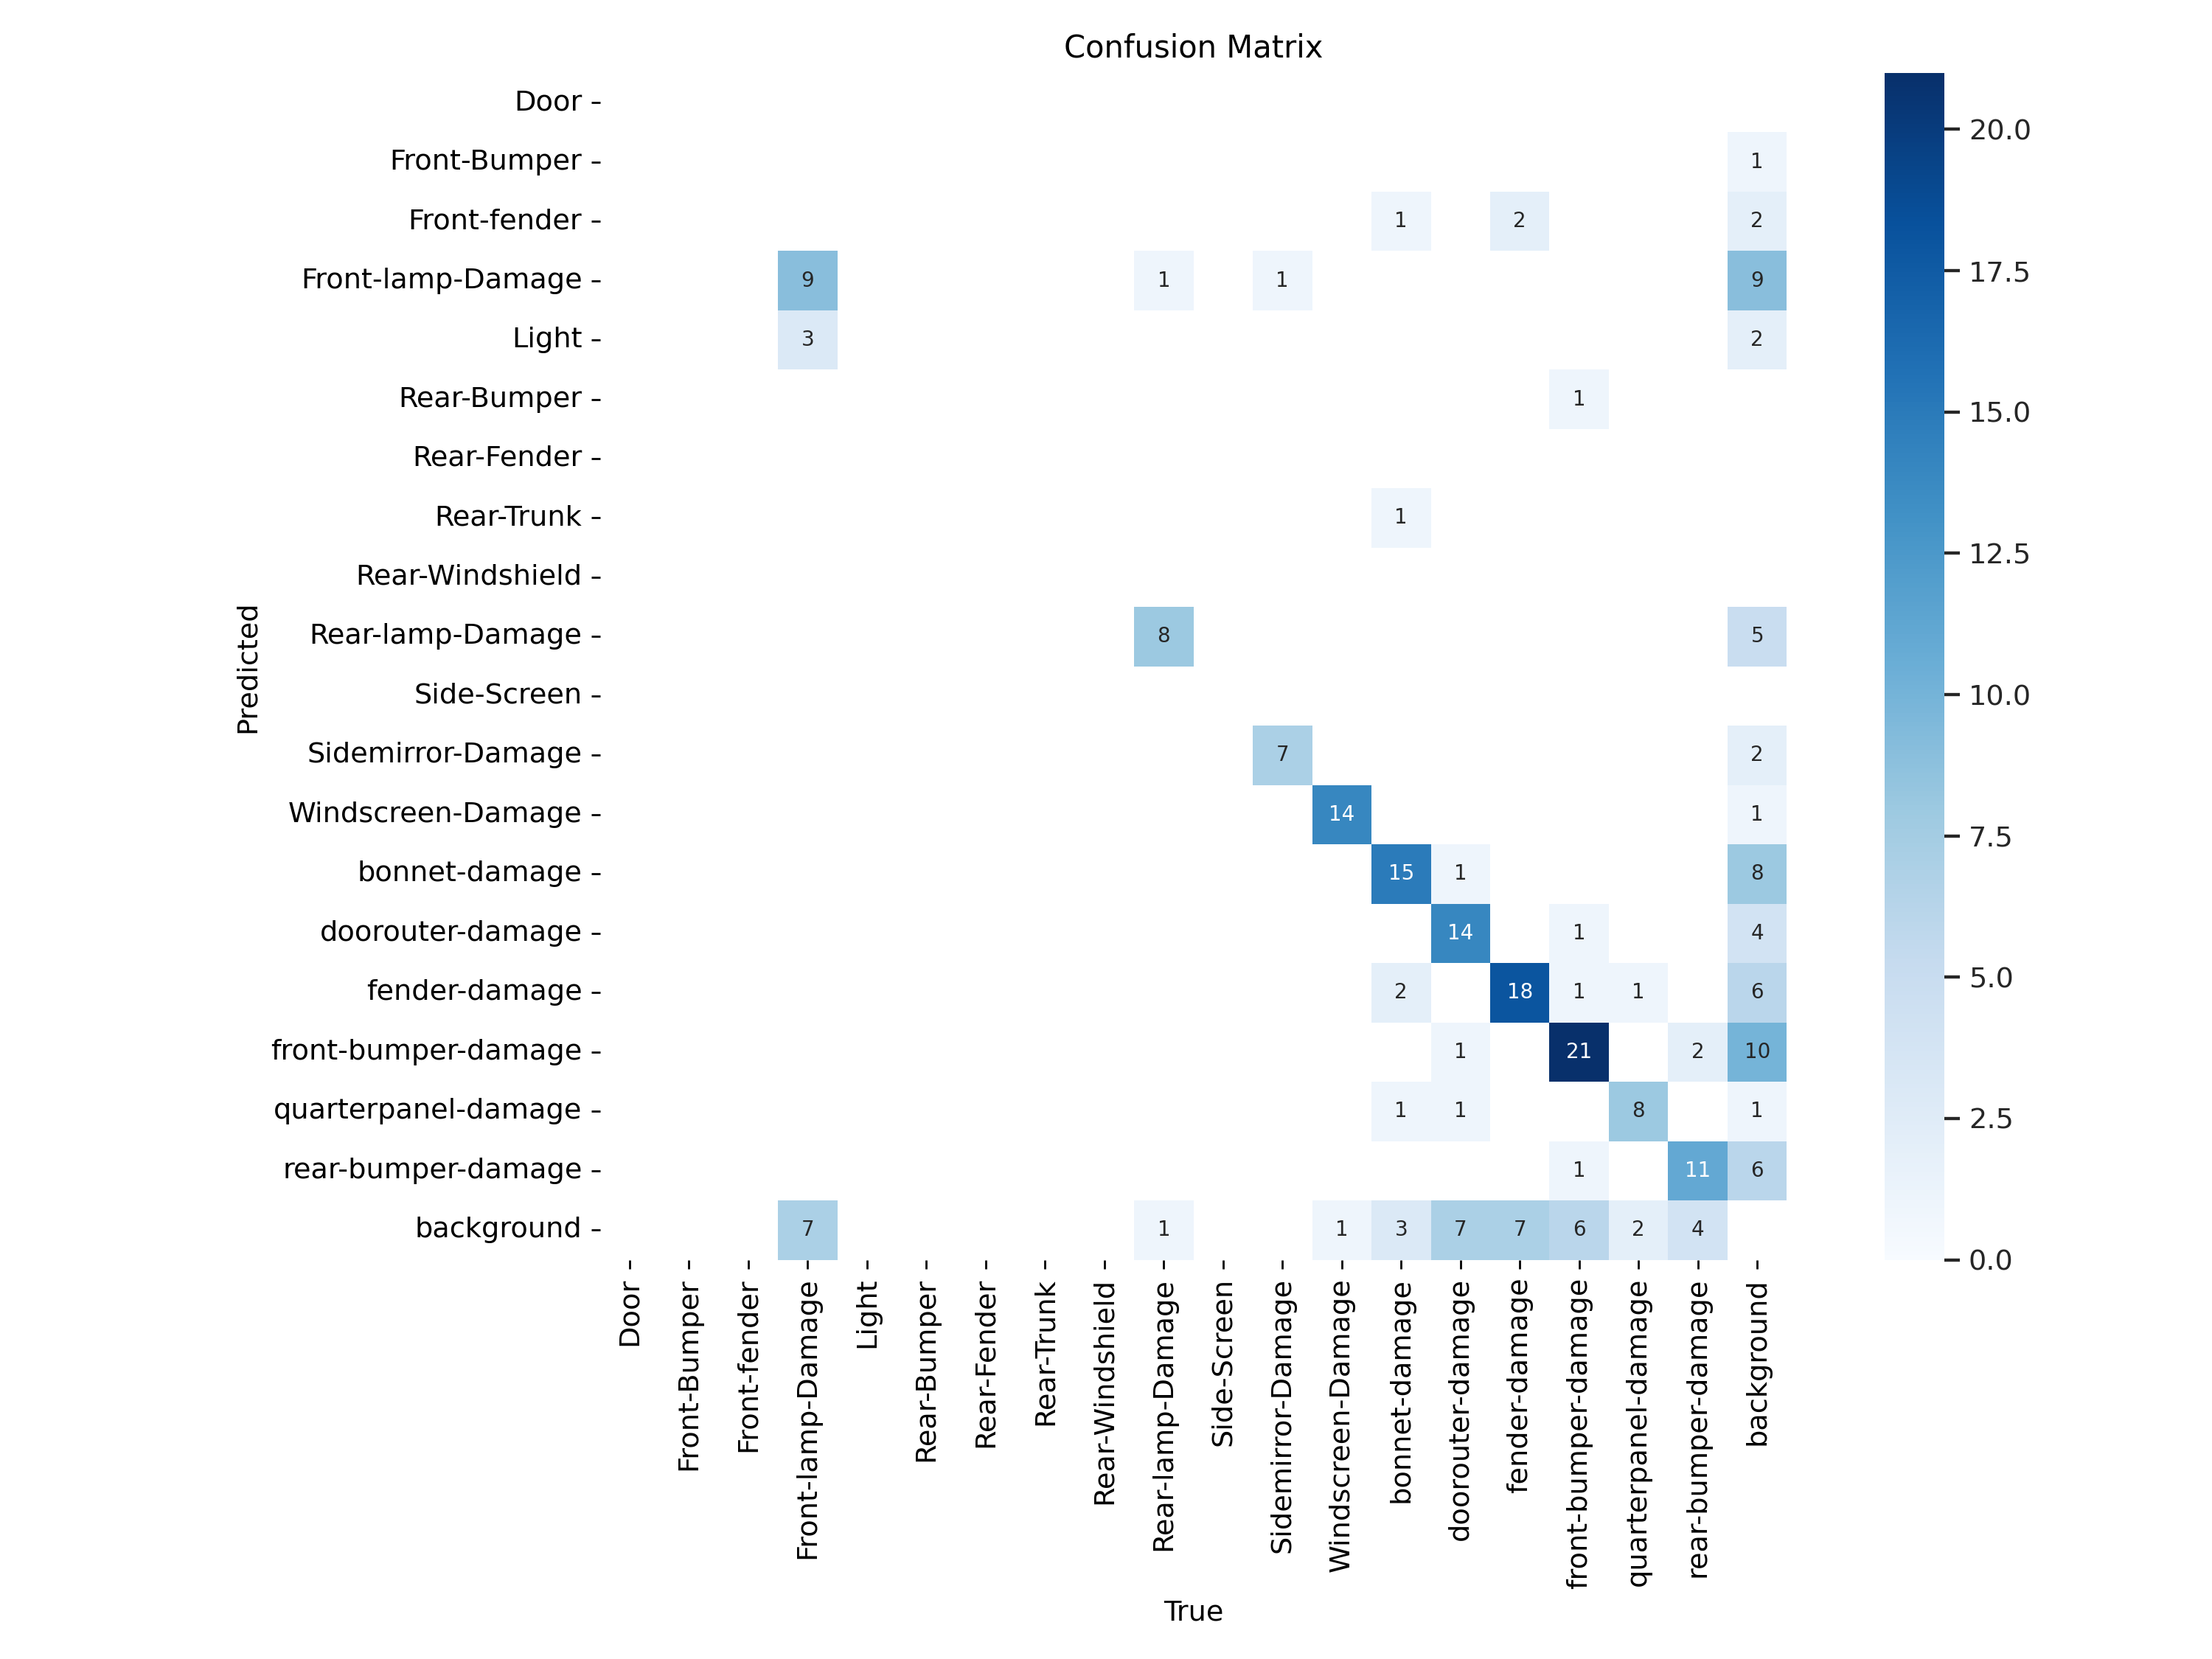

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/content


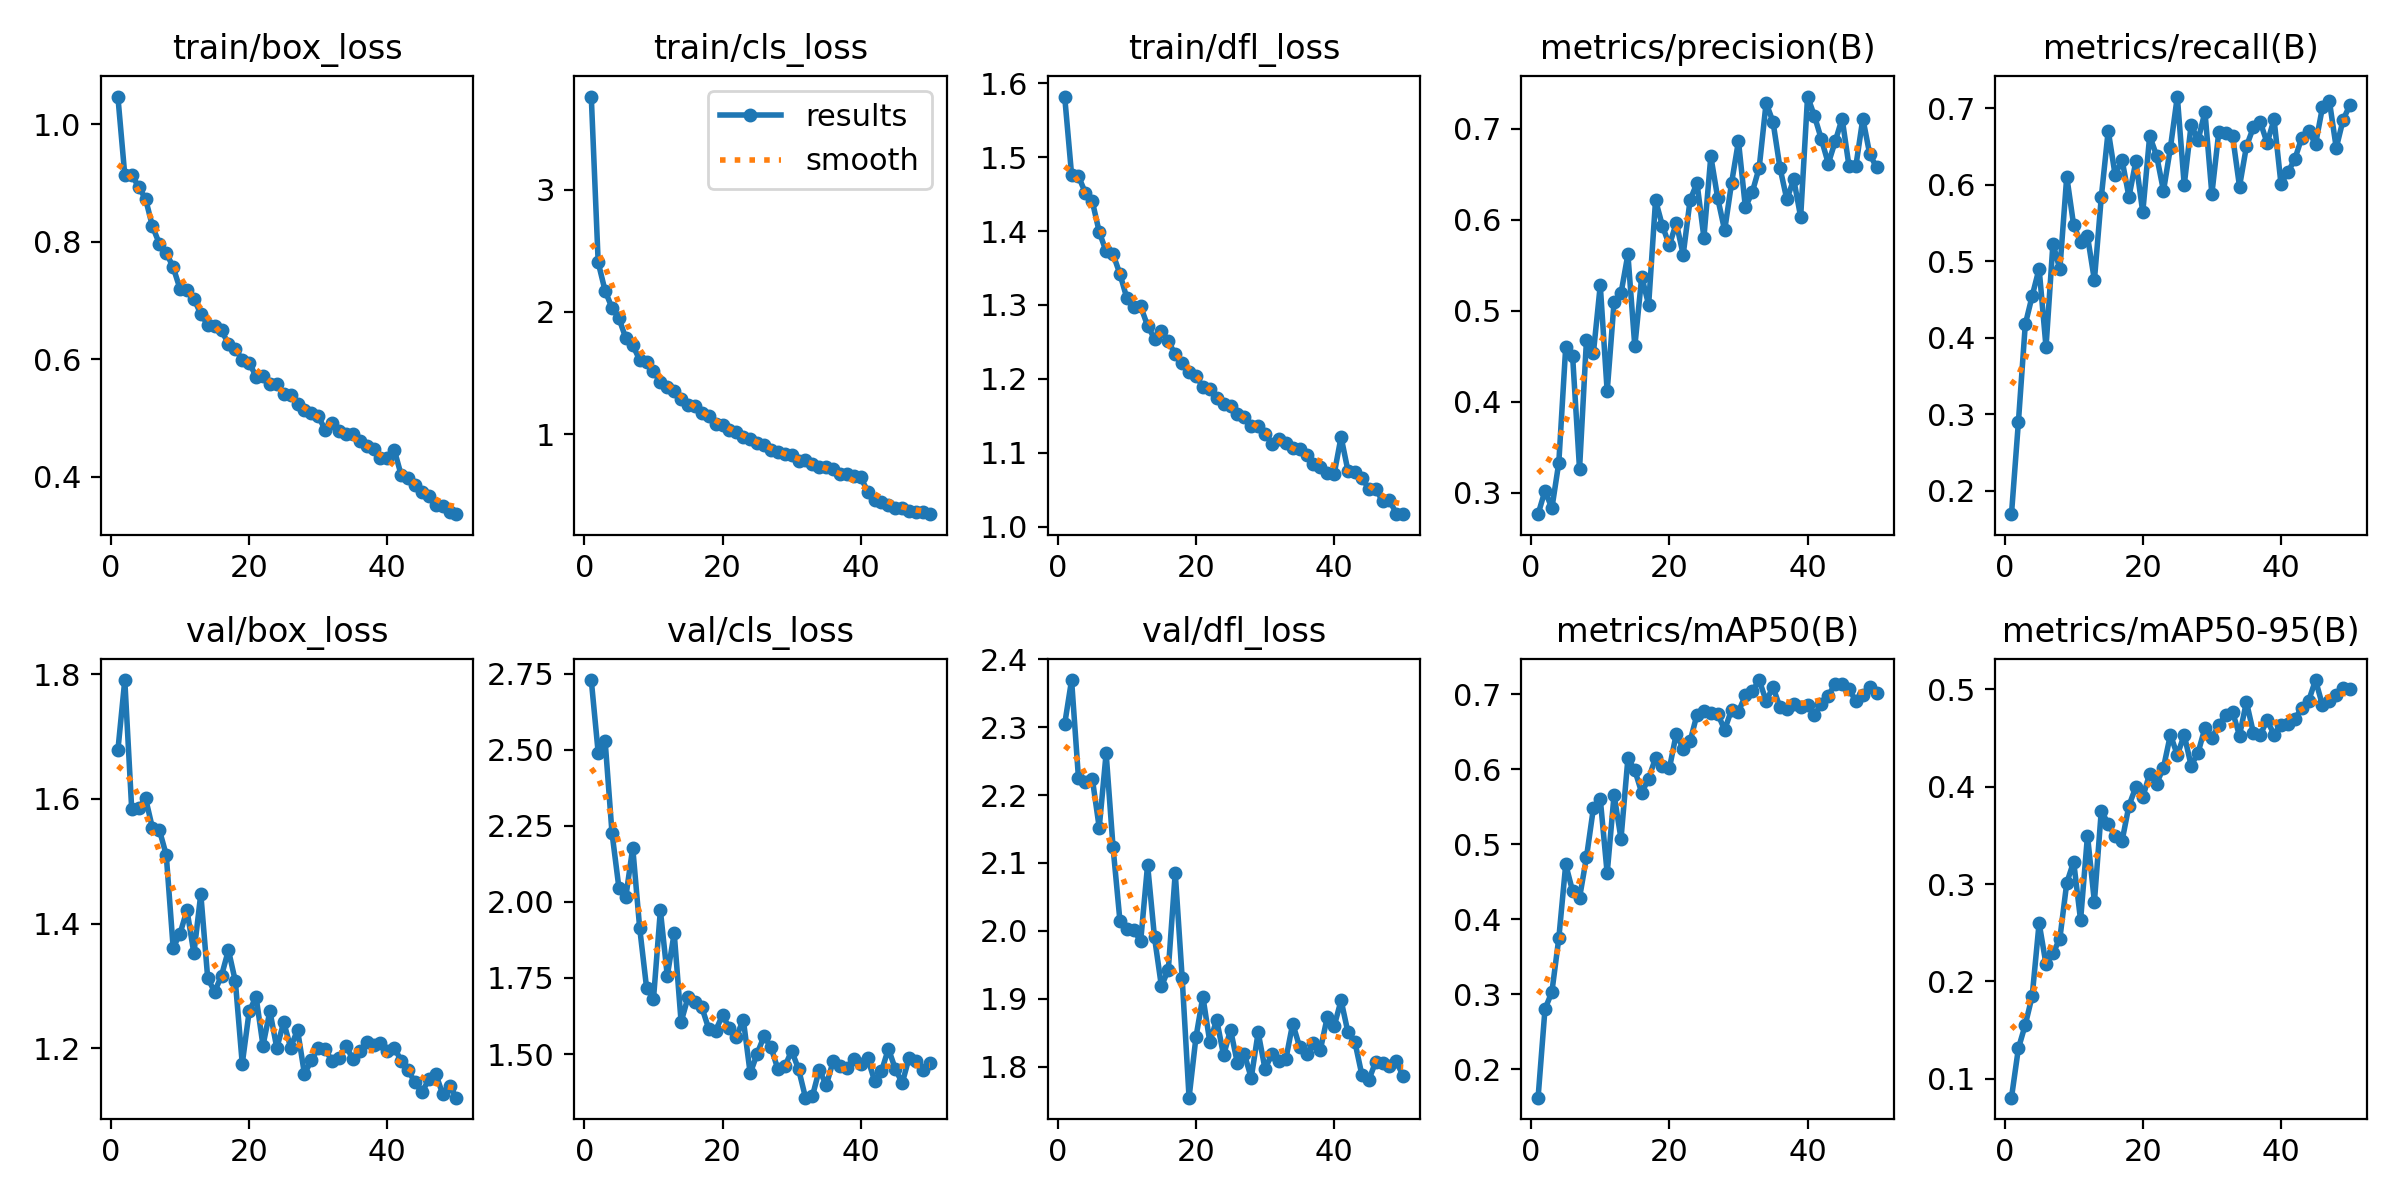

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/content


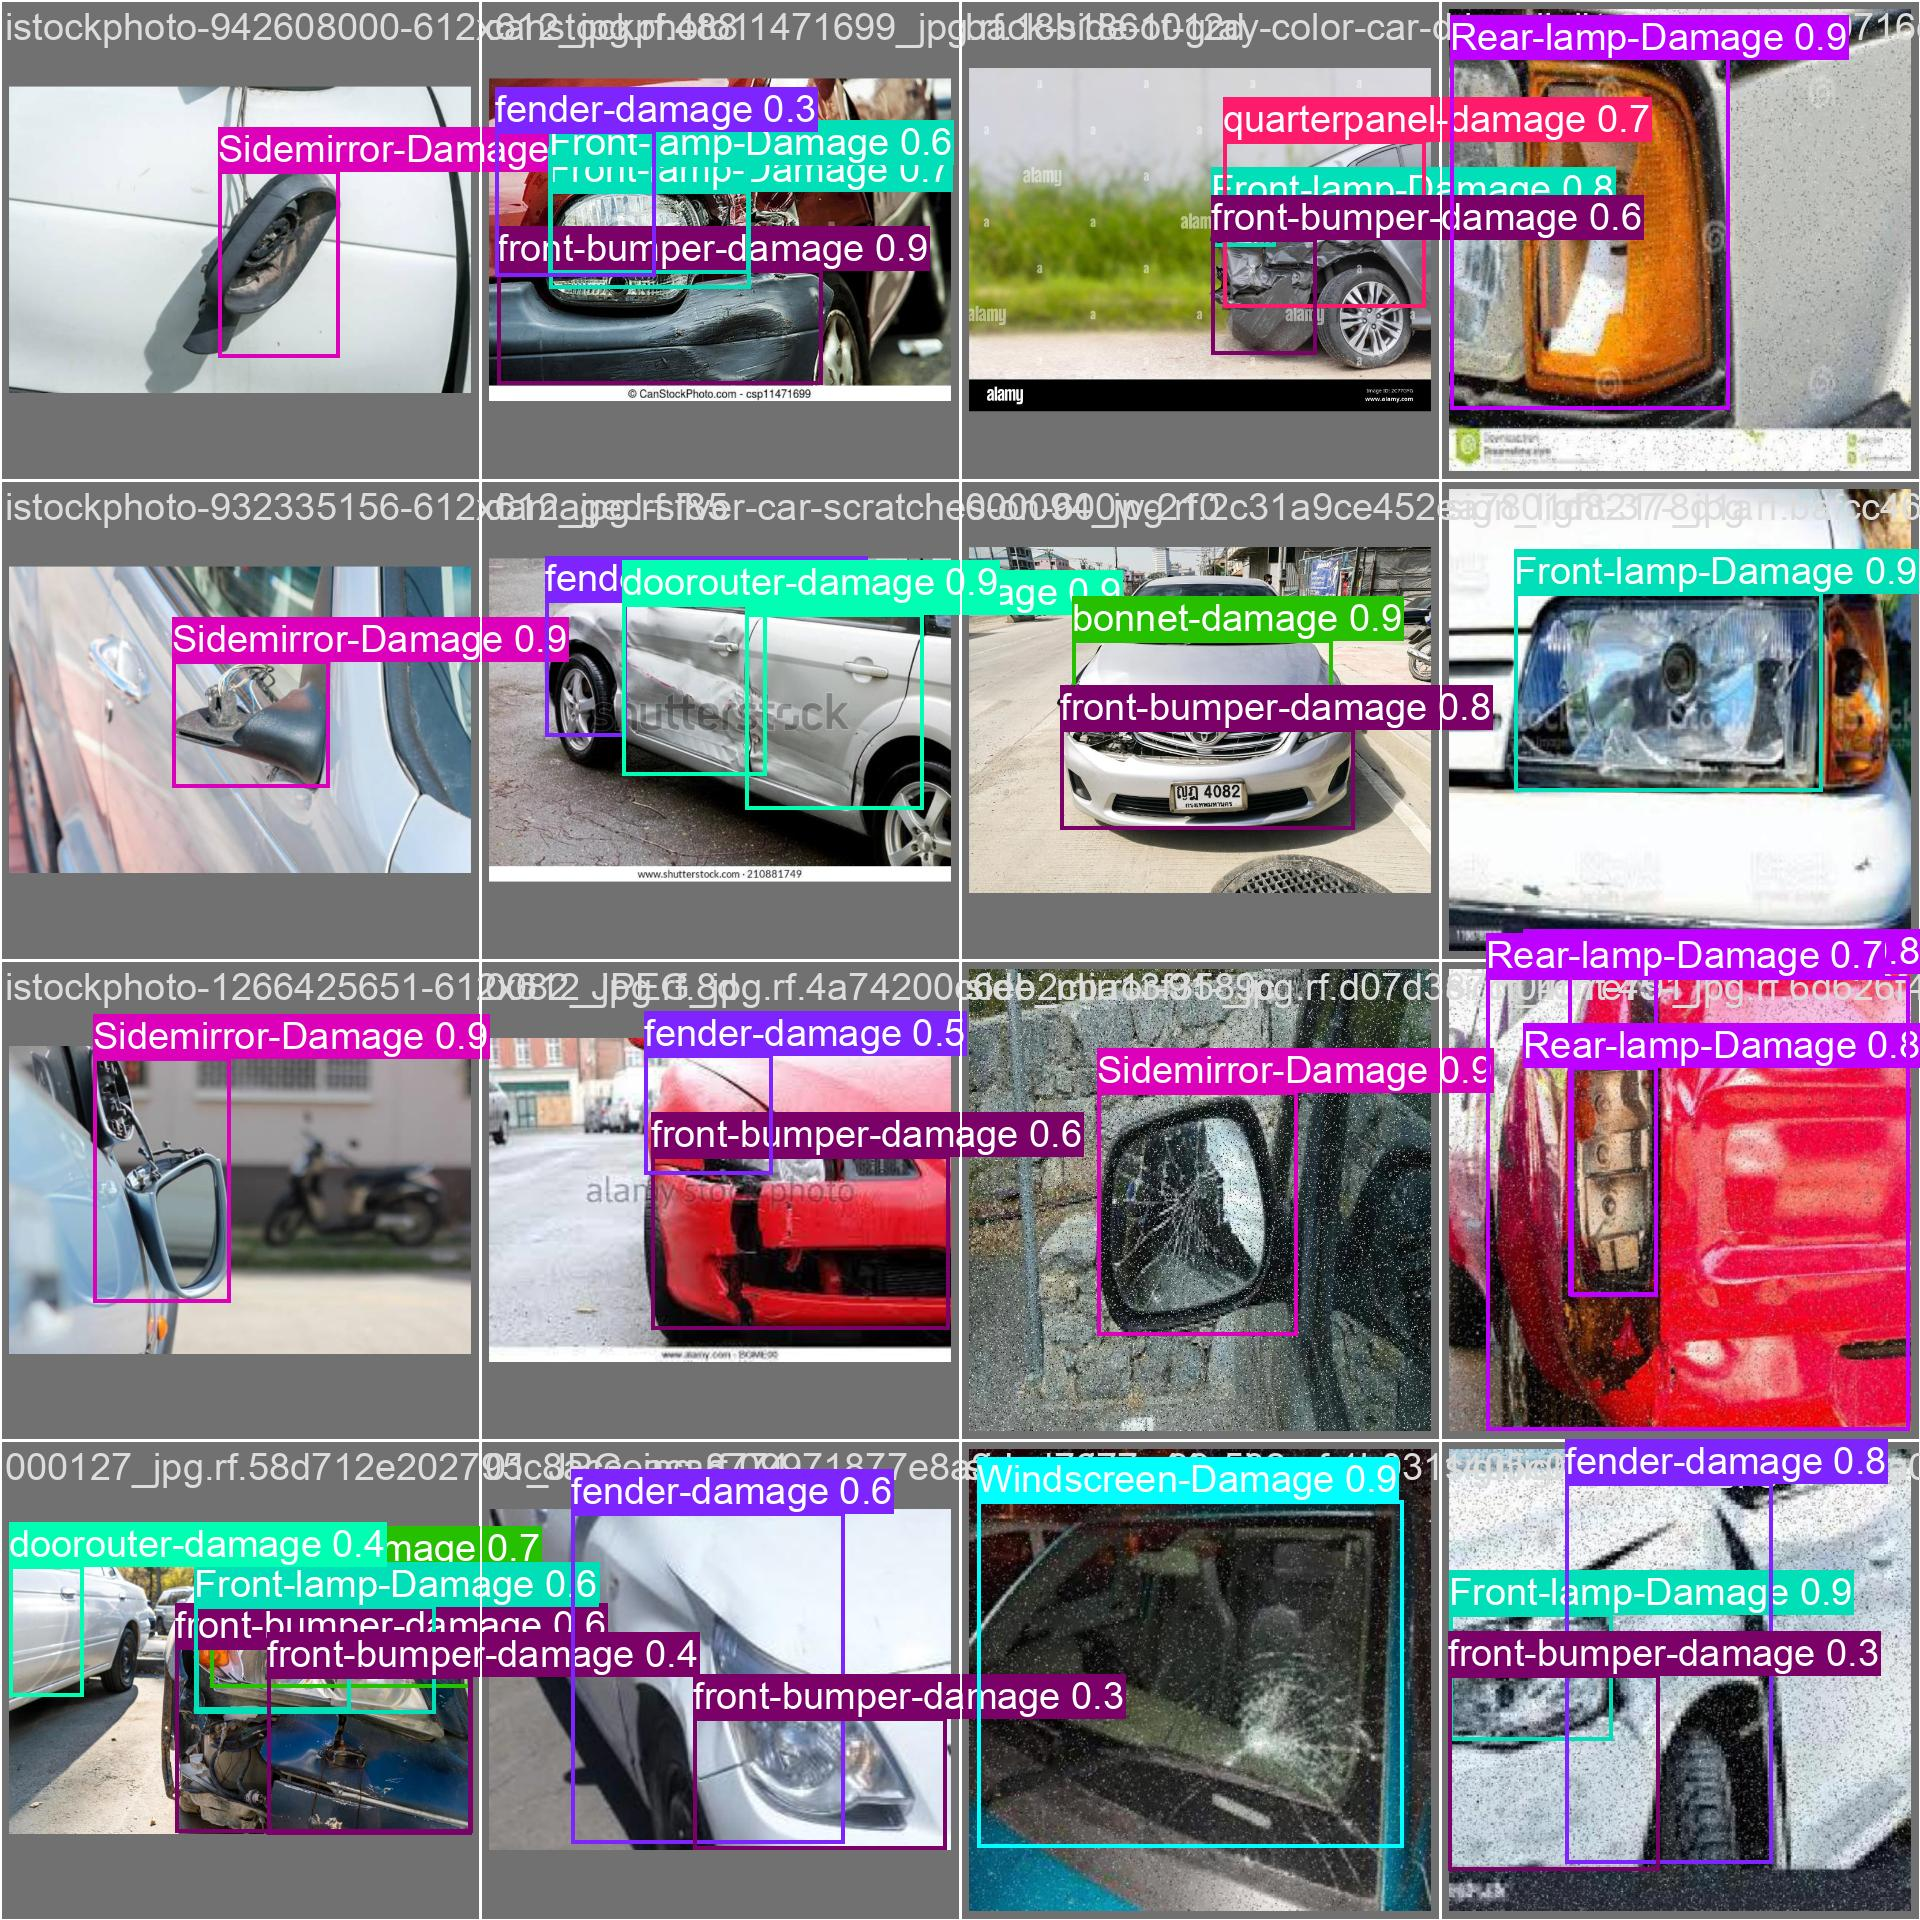

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [ ]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 11,132,937 parameters, 0 gradients, 28.5 GFLOPs
val: Scanning /content/Car-Recognition-v2-1/valid/labels.cache... 124 images, 0 backgrounds, 0 corrupt: 100% 124/124 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 184, len(boxes) = 185. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 8/8 [00:04<00:00,  1.91it/s]
                   all        124        185      0.711      0.653      0.714       0.51
     Front-lamp-Damage         17         19      0.521      0.458      0.512      0.295
      Rear-lamp-Damage         10         10      0.608        0.7      0.728      0.598
     Sidemirror-Damage 

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 11,132,937 parameters, 0 gradients, 28.5 GFLOPs

image 1/121 /content/Car-Recognition-v2-1/test/images/000052_jpg.rf.832014c619f705d717b3d0601520a272.jpg: 608x800 1 Front-lamp-Damage, 1 Sidemirror-Damage, 1 front-bumper-damage, 43.8ms
image 2/121 /content/Car-Recognition-v2-1/test/images/000078_jpg.rf.3cbf5d3fff6084dd5b60e6315bf50769.jpg: 800x544 1 Rear-lamp-Damage, 37.6ms
image 3/121 /content/Car-Recognition-v2-1/test/images/000535_jpg.rf.6fd3acc146d2820562aad6d5a965d032.jpg: 544x800 1 front-bumper-damage, 38.1ms
image 4/121 /content/Car-Recognition-v2-1/test/images/001566_jpg.rf.7b46307baafcbf3d78ea2eeeee167648.jpg: 608x800 1 bonnet-damage, 1 front-bumper-damage, 19.0ms
image 5/121 /content/Car-Recognition-v2-1/test/images/0109_JPEG_jpg.rf.8aebabb09b147556fa4fec2ad841e283.jpg: 800x800 1 doorouter-damage, 1 fender-damage, 23.5ms
image 6/121 /content/Car-R

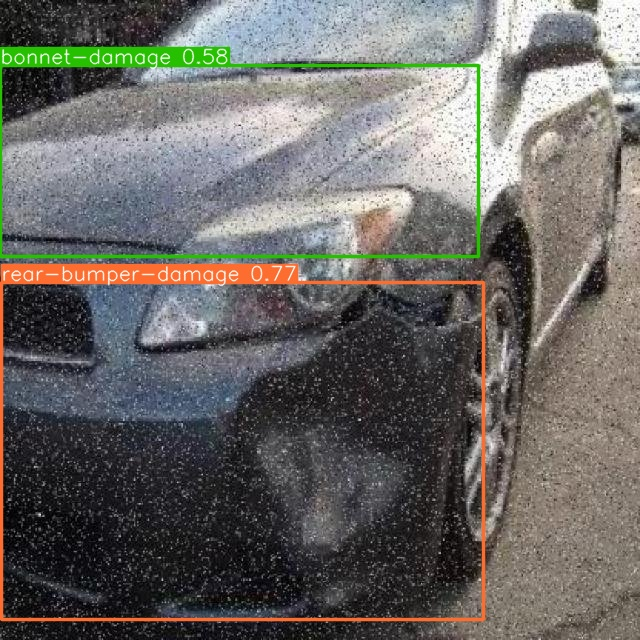

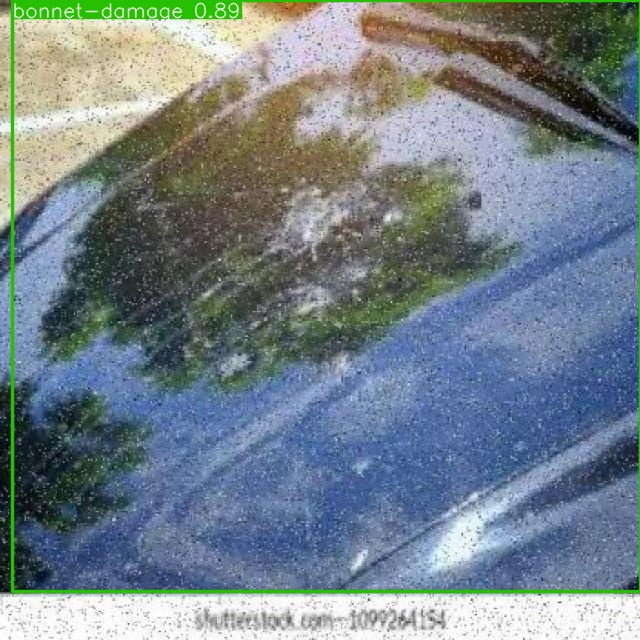

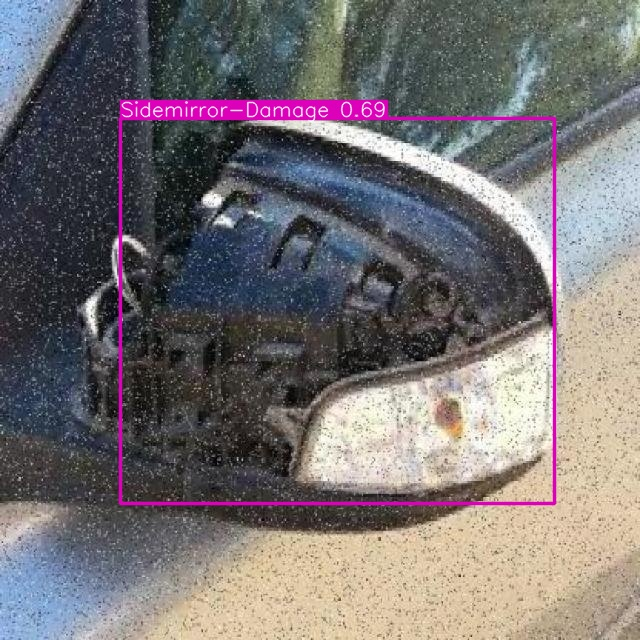

In [ ]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/content/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/Car-Recognition-v2-1/data.yaml


Ultralytics YOLOv8.2.103 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 11,132,937 parameters, 0 gradients, 28.5 GFLOPs
val: Scanning /content/Car-Recognition-v2-1/valid/labels.cache... 124 images, 0 backgrounds, 0 corrupt: 100% 124/124 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 184, len(boxes) = 185. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 8/8 [00:04<00:00,  1.88it/s]
                   all        124        185      0.711      0.653      0.714       0.51
     Front-lamp-Damage         17         19      0.521      0.458      0.512      0.295
      Rear-lamp-Damage         10         10      0.608        0.7      0.728      0.598
     Sidemirror-Damage          